# Spotify Track Popularity Analysis

## Project Overview
This project explores how Spotify audio features relate to track popularity.

Using Spotify track data, the analysis focuses on:
- cleaning and preparing the dataset,
- exploring the distribution of popularity,
- segmenting tracks by popularity level,
- identifying which audio features vary the most across popularity groups.

The objective is to better understand the profile of more popular tracks and build a clean dataset for further analysis and visualization.

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

##  Load Data / Chargement des données

In [2]:
# Import main libraries for data manipulation, visualization, and calculations
# Load Spotify dataset from Hugging Face
from datasets import load_dataset

# Load dataset from Hugging Face
dataset = load_dataset("maharshipandya/spotify-tracks-dataset", split="train")

# Convert to pandas DataFrame
df = pd.DataFrame(dataset)

df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset.csv:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/114000 [00:00<?, ? examples/s]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Data Overview

The dataset contains track-level information from Spotify, including:
- track and artist names,
- popularity score,
- audio features such as danceability, energy, valence, tempo, loudness, and duration.

The next step is to assess data quality and prepare the dataset for analysis.

In [160]:
df.shape

(114000, 21)

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [162]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
artists,1
track_name,1
album_name,1


Only a very small number of missing values were found in text columns (artists, album_name, track_name). Since the analysis mainly focuses on numeric audio features, these rows were kept.


## Data Cleaning


To make the dataset more reliable for analysis, the following cleaning steps are applied:
- removing irrelevant columns,
- standardizing text fields,
- filtering implausible values,
- creating a duration variable in minutes.

Main cleaning steps included removing irrelevant columns, standardizing text fields, removing exact duplicates, filtering implausible numeric values, and creating a duration variable in minutes.

In [163]:
# Remove columns not relevant for popularity and audio feature analysis
df_clean = df.drop(columns=["Unnamed: 0", "album_name", "time_signature", "track_genre"])

In [164]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   track_name        113999 non-null  object 
 3   popularity        114000 non-null  int64  
 4   duration_ms       114000 non-null  int64  
 5   explicit          114000 non-null  bool   
 6   danceability      114000 non-null  float64
 7   energy            114000 non-null  float64
 8   key               114000 non-null  int64  
 9   loudness          114000 non-null  float64
 10  mode              114000 non-null  int64  
 11  speechiness       114000 non-null  float64
 12  acousticness      114000 non-null  float64
 13  instrumentalness  114000 non-null  float64
 14  liveness          114000 non-null  float64
 15  valence           114000 non-null  float64
 16  tempo             11

In [165]:
# Normalize artist and track names to avoid duplicates due to case, spacing, or featuring
def normalize_text(s):
    if pd.isna(s):
        return s
    s = str(s).lower().strip().replace("&", " and ")
    for token in ["feat.", "ft.", "(feat", "(ft", "featuring"]:
        s = s.replace(token, "")
    return " ".join(s.split())

df_clean["artist_norm"] = df_clean["artists"].apply(normalize_text)
df_clean["track_norm"] = df_clean["track_name"].apply(normalize_text)

In [166]:
# Remove exact duplicates after normalization
df_clean = df_clean.drop_duplicates()

In [167]:
duplicate_count = df_clean.duplicated().sum()
duplicate_count

np.int64(0)

All duplicates removed; dataset ready for analysis

In [168]:
df_clean.shape

(90461, 19)

In [169]:
# Filter out audio or duration values that are unrealistic/outliers
df_clean = df_clean[(df_clean["tempo"] > 30) & (df_clean["tempo"] < 300)]
df_clean = df_clean[(df_clean["loudness"] > -60) & (df_clean["loudness"] < 0)]
df_clean = df_clean[(df_clean["duration_ms"] > 30000) & (df_clean["duration_ms"] < 900000)]

df_clean.shape

(90083, 19)

In [170]:
# Convert duration from milliseconds to minutes for better readability
df_clean["duration_min"] = df_clean["duration_ms"] / 60000

In [171]:
df_clean.shape

(90083, 20)

In [172]:
df_clean.head(2)

,track_id,artists,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,artist_norm,track_norm,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,gen hoshino,comedy,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,ben woodward,ghost - acoustic,2.493500


## Popularity Distribution

The popularity variable is central to this analysis.
The following visualizations help assess how tracks are distributed across popularity levels.

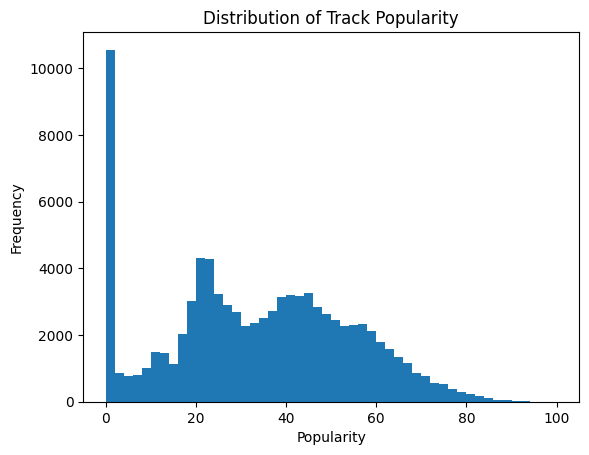

In [173]:
df_clean["popularity"].plot.hist(bins=50)
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity")
plt.show()

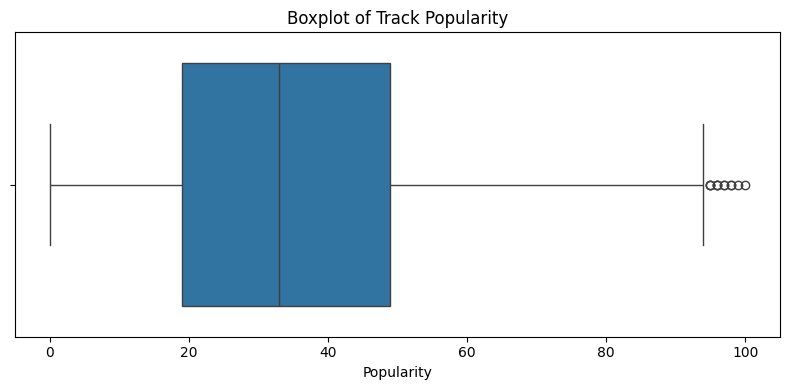

In [174]:
#Boxplot : visualize outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["popularity"])
plt.title("Boxplot of Track Popularity")
plt.xlabel("Popularity")
plt.tight_layout()
plt.show()

The boxplot confirms that most tracks have low to medium popularity scores, with a few highly popular tracks appearing as upper-end outliers.
est parfaite. Pas besoin d’expliquer les quartiles ou médiane, tu restes simple et clair pour un recruteur.

Feature Distribution Example: Energy / Exemple de distribution d’une variable : l’énergie

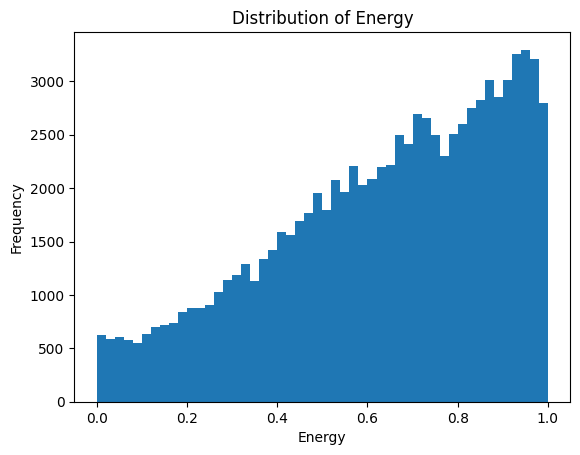

In [175]:
df_clean['energy'].plot.hist(bins=50)
plt.title("Distribution of Energy")
plt.xlabel("Energy")
plt.show()

## Popularity Segmentation / Segmentation de la popularité

To make comparisons easier, tracks are grouped into five popularity segments.
This allows us to compare average audio features across different popularity levels.




In [176]:
#buckets made based on score distribution
def popularity_segment(score):
    if score <= 10:
        return "0 Non-popular"
    elif score <= 20:
        return "1 Low popular"
    elif score <= 40:
        return "2 Medium popular"
    elif score <= 60:
        return "3 High popular"
    else:
        return "4 Super popular"

df_clean["popularity_segment"] = df_clean["popularity"].apply(popularity_segment)

df_clean["popularity_segment"] = pd.Categorical(
    df_clean["popularity_segment"],
    categories=[
        "0 Non-popular",
        "1 Low popular",
        "2 Medium popular",
        "3 High popular",
        "4 Super popular"
    ],
    ordered=True
)

df_clean["popularity_segment"].value_counts().sort_index()

,count
popularity_segment,
0 Non-popular,14685
1 Low popular,10491
2 Medium popular,30006
3 High popular,25965
4 Super popular,8936


More popular tracks tend to have slightly higher danceability and energy, while acousticness shows a different pattern across segments. Popularity is associated with a combination of audio features rather than a single dominant variable.

# New visualization

Chart comparing popularity segments with the other variables

In [177]:
features = ["danceability", "energy", "valence", "acousticness", "tempo", "duration_min"]

segment_summary = df_clean.groupby("popularity_segment")[features].mean().round(2)
segment_summary

/tmp/ipykernel_9150/447534766.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = df_clean.groupby("popularity_segment")[features].mean().round(2)


,danceability,energy,valence,acousticness,tempo,duration_min
popularity_segment,,,,,,
0 Non-popular,0.58,0.59,0.49,0.35,119.66,3.78
1 Low popular,0.53,0.67,0.43,0.29,124.74,3.89
2 Medium popular,0.55,0.66,0.49,0.33,122.81,3.79
3 High popular,0.57,0.62,0.44,0.34,122.75,3.80
4 Super popular,0.60,0.64,0.49,0.27,120.60,3.63


In [178]:
#Choose some variables as example
columns_to_plot = ["danceability", "energy", "valence", "acousticness"]

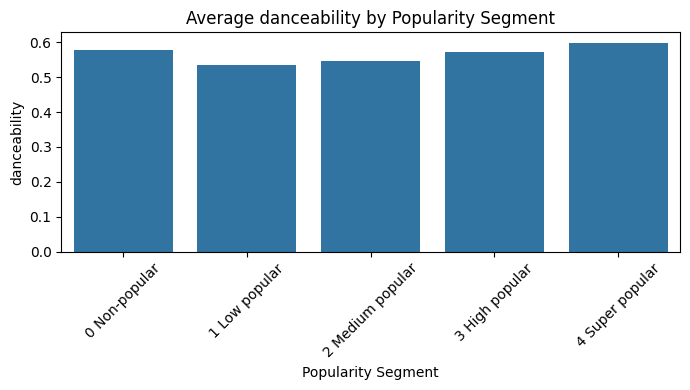

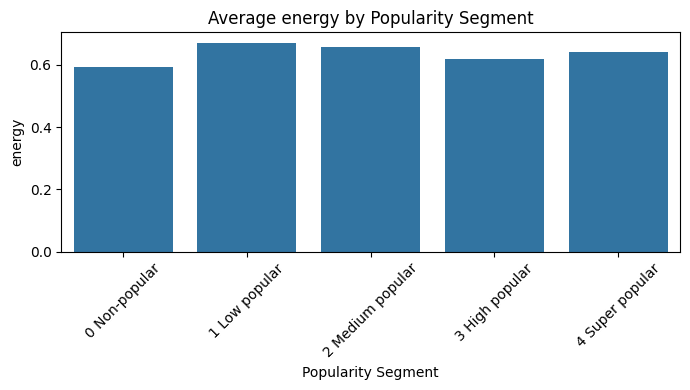

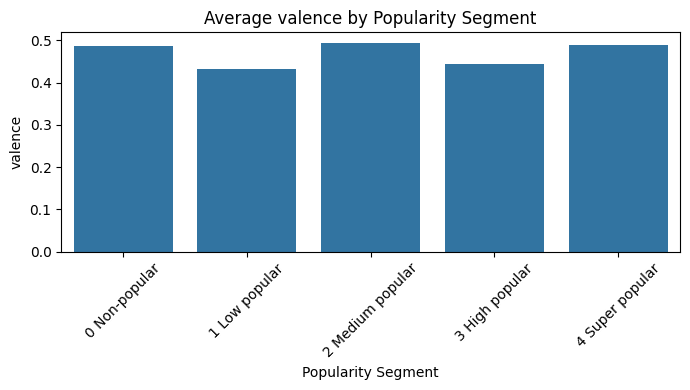

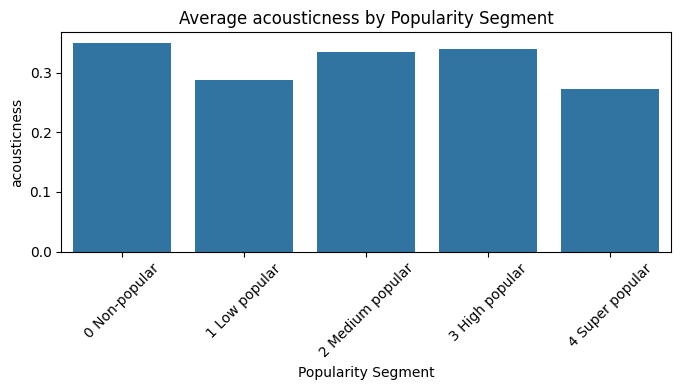

In [179]:
for column in columns_to_plot:
    plt.figure(figsize=(7, 4))
    sns.barplot(x="popularity_segment", y=column, data=df_clean, errorbar=None)
    plt.title(f"Average {column} by Popularity Segment")
    plt.xlabel("Popularity Segment")
    plt.ylabel(column)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

These barplots show the average values of selected audio features across popularity segments, highlighting small but visible differences.

In [180]:
# Check correlations between popularity and audio features
numeric_cols = ["popularity", "danceability", "energy", "valence", "acousticness", "tempo", "duration_min"]
df_clean[numeric_cols].corr()["popularity"].sort_values(ascending=False)

,popularity
popularity,1.000000
danceability,0.064794
energy,0.012765
tempo,0.007886
valence,-0.012572
duration_min,-0.018885
acousticness,-0.037599


Correlations with popularity are weak across all selected features, suggesting that popularity is likely driven by a combination of audio characteristics rather than a single variable.

## Key Insights

A few patterns emerge from the analysis:

- track popularity is unevenly distributed, with many tracks concentrated in lower and medium popularity ranges;
- some audio features such as danceability, energy, and valence show visible differences across popularity segments;
- popularity does not depend on a single variable, but rather on a combination of musical characteristics.

This analysis provides a clean foundation for deeper exploration, such as predictive modeling or clustering.

## Conclusion

This project cleaned and explored Spotify track data to better understand popularity patterns.

The analysis showed how audio features can be compared across popularity groups and highlighted the importance of structured data cleaning before interpretation.

Possible next steps include:
- predictive modeling of track popularity,
- clustering tracks by audio profile,
- comparing genres or artists in more detail.



# Key Insights & Next Steps
# → Popularity depends on multiple audio features
# → Clean dataset ready for predictive modeling or clustering